# Incremental PCA on ImageNet Activations with imgANN

This notebook extracts ImageNet validation activations from an ANN through the local `imgANN` interface and fits `sklearn.decomposition.IncrementalPCA` without loading all activations into memory at once.

## Setup

In [ ]:
from pathlib import Path
import gc
import json
import os
import random
import sys
from dataclasses import asdict, dataclass, field
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from sklearn.decomposition import IncrementalPCA
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageNet
from tqdm.auto import tqdm

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.image_processing.computational_models import imgANN, pool_features
from useful_stuff.general_utils import get_device

## Configuration

In [ ]:
@dataclass
class Cfg:
    # Model options passed to imgANN. Keep pkg="hf" so weights are downloaded only from Hugging Face.
    model_name: str = "microsoft/resnet-18"
    pkg: str = "hf"
    weights_type: str | None = None
    dtype: str = "float32"
    attn_implementation: str | None = None
    repo_url: str | None = None
    revision: str | None = None
    trust_remote_code: bool = False
    image_size: int = 224
    target_layers: list[str] = field(default_factory=lambda: ["encoder.stages.0.layers.1.activation"])

    # ImageNet root from ../../config.yaml, matching visualize_imagenet_validation.ipynb.
    imagenet_root: str = paths["imagenet_path"]

    # Loader/inference controls.
    batch_size: int = 100
    num_workers: int = 4
    pin_memory: bool = True
    use_mixed_precision: bool = True
    extraction_method: str = "hook"  # "hook" expects module paths; "fx" expects torchvision FX node names.

    # Feature shape controls. Use one of: "flatten", "spatial_mean", "token_mean", "cls_token".
    # "flatten" keeps all CNN spatial positions or all transformer tokens as features.
    pooling: str = "all"

    # iPCA controls. batch_size must be >= n_components for sklearn IncrementalPCA.
    n_components: int = 10
    ipca_batch_size: int | None = None  # None means use DataLoader batch size.
    transform_embeddings: bool = False

    # Debug controls.
    max_images: int | None = 1024  # e.g. 1024 for a quick smoke test.
    seed: int = 7

    # Output location.
    output_dir: str = str(Path(paths["data_path"]) / "imagenet_ipca")
    run_name: str | None = None


cfg = Cfg()
assert cfg.pkg == "hf", "This notebook is configured to download models only from Hugging Face."

run_dir = Path(cfg.output_dir) / cfg.run_name
# run_dir.mkdir(parents=True, exist_ok=True)
cfg

Cfg(model_name='microsoft/resnet-18', pkg='hf', weights_type=None, dtype='float32', attn_implementation=None, repo_url=None, revision=None, trust_remote_code=False, image_size=224, target_layers=['encoder.stages.0.layers.1.activation'], imagenet_root='/Users/tizianocausin/datasets/imagenet', batch_size=100, num_workers=4, pin_memory=True, use_mixed_precision=True, extraction_method='hook', pooling='all', n_components=10, ipca_batch_size=None, transform_embeddings=False, max_images=1024, seed=7, output_dir='/Users/tizianocausin/sd_local/imagenet_ipca', run_name='microsoft_resnet-18_hf_encoder_stages_0_layers_1_activation_ipca10_20260527_100243')

In [5]:
def set_reproducibility(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_reproducibility(cfg.seed)
device = get_device()
device

device(type='mps')

## Dataset Loading

In [6]:
imagenet_root = Path(cfg.imagenet_root).expanduser()
assert imagenet_root.exists(), f"ImageNet root does not exist: {imagenet_root}"

preprocess = transforms.Compose([
    transforms.Resize(cfg.image_size),
    transforms.CenterCrop(cfg.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = ImageNet(root=imagenet_root, split="val", transform=preprocess)
assert len(dataset) == 50_000, f"Expected 50,000 validation images, found {len(dataset):,}"

if cfg.max_images is not None:
    rng = np.random.default_rng(cfg.seed)
    subset_indices = rng.choice(len(dataset), size=min(cfg.max_images, len(dataset)), replace=False)
    dataset = Subset(dataset, subset_indices.tolist())

loader = DataLoader(
    dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and torch.cuda.is_available(),
    persistent_workers=cfg.num_workers > 0,
)

classes = dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes
len(dataset), len(loader), classes[:5]

(1024,
 11,
 [('tench', 'Tinca tinca'),
  ('goldfish', 'Carassius auratus'),
  ('great white shark',
   'white shark',
   'man-eater',
   'man-eating shark',
   'Carcharodon carcharias'),
  ('tiger shark', 'Galeocerdo cuvieri'),
  ('hammerhead', 'hammerhead shark')])

## Model Initialization

In [8]:
HF_DTYPES = {
    "float32": torch.float32,
    "float16": torch.float16,
    "bfloat16": torch.bfloat16,
}

ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.image_size,
    relevant_layers=cfg.target_layers,
    pooling=cfg.pooling,  # keep raw activations; postprocess them below in a model-agnostic way.
    weights_type=cfg.weights_type,
    dtype=HF_DTYPES[cfg.dtype],
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.repo_url,
    revision=cfg.revision,
    trust_remote_code=cfg.trust_remote_code,
)
ann.set_device(device)
ann.get_model().eval()
if cfg.extraction_method == "hook":
    features_dict, hook_handles = ann.create_forward_hook(cfg.target_layers)
elif cfg.extraction_method == "fx":
    feature_extractor = ann.create_feature_extractor(cfg.target_layers)
else:
    raise ValueError(f"Unsupported extraction_method: {cfg.extraction_method}")

ann

10:03:19 - device being used: mps


ANN(model=microsoft/resnet-18, pkg=hf, pooling=all, device=mps, img_size=224)

## Incremental PCA Fitting

In [9]:
n_components = cfg.n_components
ipca_batch_size = cfg.ipca_batch_size or cfg.batch_size
assert ipca_batch_size >= n_components, "IncrementalPCA requires each partial_fit batch to have at least n_components samples."
ipcas = {layer: IncrementalPCA(n_components=min(n_components, np.prod(ann.get_layer_output_shape(layer))), batch_size=ipca_batch_size) for layer in cfg.target_layers}

for images, _ in tqdm(loader, desc="Fitting IncrementalPCA"):
    images = images.to(device)
    ann.model(images)
    for layer, features in ann.features.items():
        features = features.detach().cpu().numpy()
        ipcas[layer].partial_fit(features)
{layer: ipca.explained_variance_ratio_[:5] for layer, ipca in ipcas.items()}

Fitting IncrementalPCA:   0%|          | 0/11 [00:03<?, ?it/s]

{'encoder.stages.0.layers.1.activation': array([0.01438396, 0.00755552, 0.00689173, 0.00591968, 0.00537799])}

In [16]:
ipcas.keys()

dict_keys(['encoder.stages.3.layers.1.activation'])

Projecting random images:   0%|          | 0/6 [00:03<?, ?it/s]

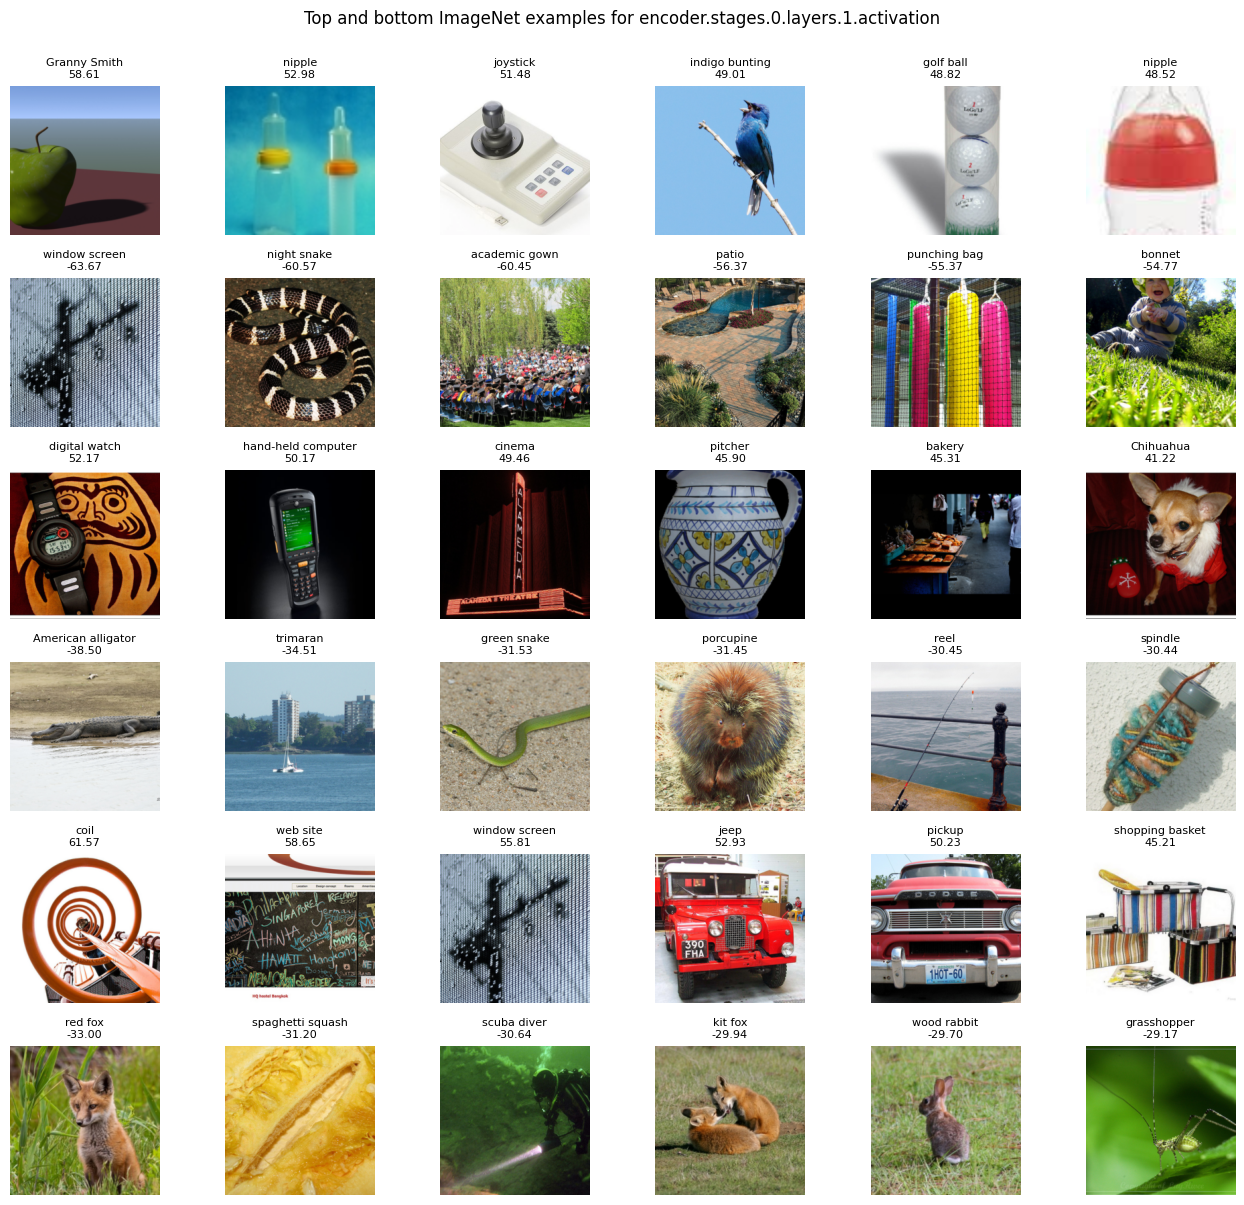

In [15]:
sample_n = 512
n_extreme = 6
n_pcs_to_show = 3
layer = cfg.target_layers[0]

rng = np.random.default_rng(cfg.seed + 1)
viz_indices = rng.choice(len(dataset), size=min(sample_n, len(dataset)), replace=False).tolist()
viz_dataset = Subset(dataset, viz_indices)
viz_loader = DataLoader(
    viz_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory and torch.cuda.is_available(),
    persistent_workers=cfg.num_workers > 0,
)

viz_images = []
viz_targets = []
viz_features = []

ann.get_model().eval()
for images, targets in tqdm(viz_loader, desc="Projecting random images"):
    viz_images.append(images.cpu())
    viz_targets.append(targets.cpu())

    images = images.to(device, non_blocking=True)
    with torch.inference_mode():
        if cfg.pkg == "hf":
            ann.model(pixel_values=images)
        else:
            ann.model(images)

    features = ann.features[layer].detach().float().cpu().numpy()
    viz_features.append(features)

viz_images = torch.cat(viz_images)
viz_targets = torch.cat(viz_targets)
viz_features = np.concatenate(viz_features, axis=0)
viz_scores = ipcas[layer].transform(viz_features)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
classes = dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes

def show_image(ax, image, target, score):
    image = (image * std + mean).clamp(0, 1)
    class_names = classes[int(target)]
    label = class_names[0] if isinstance(class_names, tuple) else class_names
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"{label}\n{score:.2f}", fontsize=8)
    ax.axis("off")

n_pcs_to_show = min(n_pcs_to_show, viz_scores.shape[1])
fig, axes = plt.subplots(n_pcs_to_show * 2, n_extreme, figsize=(2.2 * n_extreme, 4.0 * n_pcs_to_show))
axes = np.atleast_2d(axes)

for pc_idx in range(n_pcs_to_show):
    scores = viz_scores[:, pc_idx]
    bottom_indices = np.argsort(scores)[:n_extreme]
    top_indices = np.argsort(scores)[-n_extreme:][::-1]

    axes[2 * pc_idx, 0].set_ylabel(f"PC {pc_idx + 1} top", fontsize=10)
    axes[2 * pc_idx + 1, 0].set_ylabel(f"PC {pc_idx + 1} bottom", fontsize=10)

    for col, idx in enumerate(top_indices):
        show_image(axes[2 * pc_idx, col], viz_images[idx], viz_targets[idx], scores[idx])
    for col, idx in enumerate(bottom_indices):
        show_image(axes[2 * pc_idx + 1, col], viz_images[idx], viz_targets[idx], scores[idx])

fig.suptitle(f"Top and bottom ImageNet examples for {layer}", y=1.0)
plt.tight_layout()
plt.show()